In [2]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

In [4]:
class Paths:
    p = "/Users/shirokoshikentaro/Downloads/house-prices-advanced-regression-techniques/"
    train = p + "train.csv"
    test = p + "test.csv"
    sample = p + "sample_submission.csv"

In [5]:
train = pd.read_csv(Paths.train)


In [6]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
train.shape

(1460, 81)

In [8]:
train.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object


In [9]:
train.isnull().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [10]:
numeric_features = [
    "LotArea",
    "YearBuilt",
    "YearRemodAdd",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "GarageCars",
    "GarageArea",
    "OverallQual",
    "OverallCond",
]

categorical_features = [
    "Neighborhood", "BldgType", "HouseStyle",
    "MSZoning", "Foundation", "GarageType"
]

# 欠損値を0で埋める
for col in numeric_features:
    train[col].fillna(0,inplace=True)
    test[col].fillna(0,inplace=True)

for col in categorical_features:
    train[col].fillna("None",inplace=True)
    test[col].fillna("None",inplace=True)

# カテゴリー変数のエンコーディング
# ★ カテゴリ変数のエンコーディング（修正版）
for col in categorical_features:
    # trainとtestを結合してユニークな値を全て取得
    all_data = pd.concat([train[col], test[col]], axis=0)
    
    # 結合データでLabelEncoderを学習
    le = LabelEncoder()
    le.fit(all_data.astype(str))
    
    # trainとtestをそれぞれ変換
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))


features = numeric_features + categorical_features

X_train = train[features]
y_train = train["SalePrice"]

print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")

NameError: name 'test' is not defined

<Axes: >

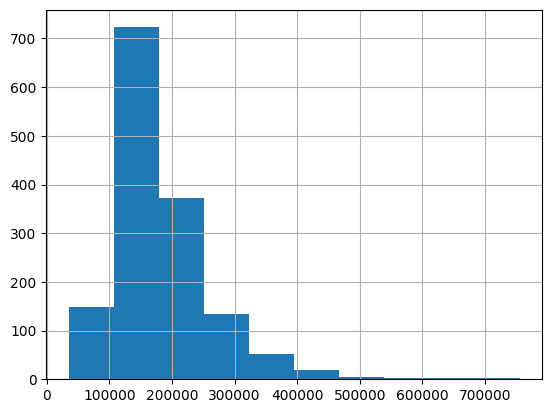

In [ ]:
train["SalePrice"].hist()

In [ ]:
params = {
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 16,
    "learning_rate": 0.1,
    "n_estimators": 10000,
    "random_state": 123,
    "verbose": -1,
}

In [ ]:
n_splits = 5

cv = KFold(n_splits=n_splits, shuffle=True, random_state=123)

metrics = []
imp = pd.DataFrame()

for nfold, (train_index, valid_index) in enumerate(cv.split(X_train, y_train)):
    print("=" * 10, nfold, "=" * 10)
    X_tr, y_tr = X_train.iloc[train_index], y_train.iloc[train_index]
    X_val, y_val = X_train.iloc[valid_index], y_train.iloc[valid_index]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=True),
            lgb.log_evaluation(0),
        ],
    )

    y_tr_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_val)

    tr_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    metrics.append([nfold,tr_rmse,val_rmse])

    _imp = pd.DataFrame(
        {
            "col": X_train.columns,
            "imp": model.feature_importances_,
            "nfold": nfold
        }
    )
    imp = pd.concat([imp, _imp], axis=0, ignore_index=True)

========== 0 ==========
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[42]	training's rmse: 23008.4	valid_1's rmse: 26665.8
========== 1 ==========
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[45]	training's rmse: 21498.2	valid_1's rmse: 33927.5
========== 2 ==========
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[288]	training's rmse: 9721.93	valid_1's rmse: 28173.3
========== 3 ==========
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[443]	training's rmse: 6613.42	valid_1's rmse: 26970.6
========== 4 ==========
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[45]	training's rmse: 22160.6	valid_1's rmse: 31450.5


In [ ]:
metrics_array = np.array(metrics)

print("[cv]tr:{:.2f}+-{:.2f},val:{:.2f}+-{:.2f}".format(
    metrics_array[:,1].mean(),
    metrics_array[:,1].std(),
    metrics_array[:,2].mean(),
    metrics_array[:,2].std(),
))

[cv]tr:16600.51+-6971.66,val:29437.53+-2813.51


In [ ]:
imp = imp.groupby("col")["imp"].agg(["mean","std"])
imp.columns = ["imp","imp_std"]

imp_df = imp.sort_values(by="imp",ascending=False)

imp_df.head(30)


,imp,imp_std
col,,
LotArea,354.0,404.034652
GarageArea,334.0,424.639847
1stFlrSF,333.8,413.822667
GrLivArea,324.2,297.739316
TotalBsmtSF,308.2,330.506732
YearBuilt,150.6,145.073430
YearRemodAdd,130.8,133.838335
Neighborhood,129.8,124.168031
2ndFlrSF,128.2,154.742367


In [ ]:
test = pd.read_csv(Paths.test)
test.shape

(1459, 80)

In [ ]:
X_test = test[features]
X_test.shape

(1459, 20)

In [ ]:
submit = pd.read_csv(Paths.sample)
submit.head(10)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977
5,1466,177150.989247
6,1467,172070.659229
7,1468,175110.956520
8,1469,162011.698832
9,1470,160726.247831


In [ ]:
y_test_pred = model.predict(X_test)

df_submit = pd.DataFrame(
    {
        "Id": test["Id"],
        "SalePrice": y_test_pred,
    }
)
df_submit

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: Neighborhood: object, BldgType: object, HouseStyle: object, MSZoning: object, Foundation: object, GarageType: object

In [ ]:
df_submit.to_csv("submit.csv",index=False)

<Axes: >

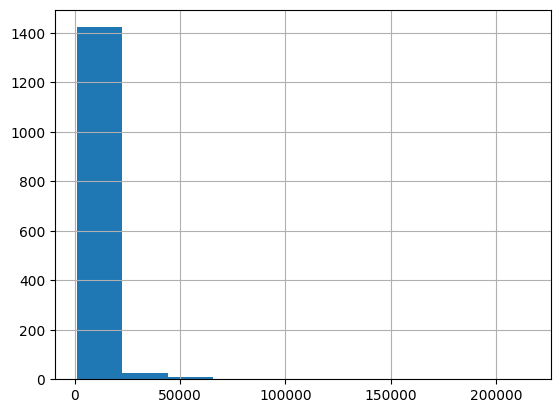

In [ ]:
train["LotArea"].hist()

<Axes: >

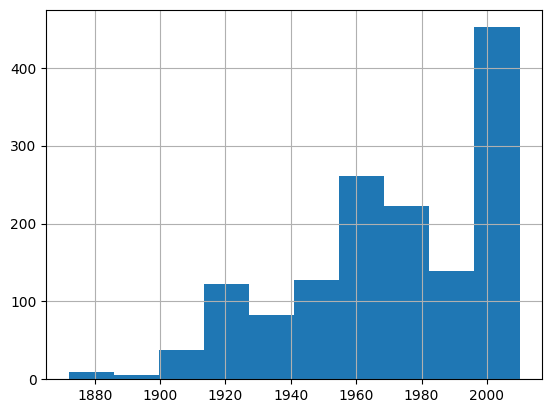

In [ ]:
train["YearBuilt"].hist()

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# === testデータで予測 ===
X_test = test[features]

print(f"\nX_test shape: {X_test.shape}")
print(f"X_test dtypes:\n{X_test.dtypes.value_counts()}")

# データ型チェック
if 'object' in X_test.dtypes.values:
    print("\n⚠️ 警告: X_testに文字列型のカラムがあります！")
    print(X_test.select_dtypes(include=['object']).columns.tolist())
else:
    print("\n✅ X_testは全て数値型です")

# 予測
y_test_pred = model.predict(X_test)

# === 提出ファイル ===
df_submit = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_test_pred,
})

print("\n提出ファイル:")
print(df_submit.head())
print(f"データ数: {len(df_submit)}")

# 保存
df_submit.to_csv("submission.csv", index=False)
print("\n✅ submission.csv を保存しました！")


X_test shape: (1459, 20)
X_test dtypes:
int64      11
object      6
float64     3
Name: count, dtype: int64

⚠️ 警告: X_testに文字列型のカラムがあります！
['Neighborhood', 'BldgType', 'HouseStyle', 'MSZoning', 'Foundation', 'GarageType']


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: Neighborhood: object, BldgType: object, HouseStyle: object, MSZoning: object, Foundation: object, GarageType: object

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Pathsクラス
class Paths:
    p = "/Users/shirokoshikentaro/Downloads/house-prices-advanced-regression-techniques/"
    train = p + "train.csv"
    test = p + "test.csv"
    sample = p + "sample_submission.csv"

# === データ読み込み ===
print("データ読み込み中...")
train = pd.read_csv(Paths.train)
test = pd.read_csv(Paths.test)

# === 特徴量定義 ===
numeric_features = [
    "LotArea", "YearBuilt", "YearRemodAdd",
    "GrLivArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
    "FullBath", "BedroomAbvGr", "TotRmsAbvGrd",
    "GarageCars", "GarageArea",
    "OverallQual", "OverallCond",
]

categorical_features = [
    "Neighborhood", "BldgType", "HouseStyle",
    "MSZoning", "Foundation", "GarageType"
]

print(f"\n使用する特徴量: {len(numeric_features)}個の数値 + {len(categorical_features)}個のカテゴリ")

# === 欠損値処理 ===
print("\n欠損値処理中...")
for col in numeric_features:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

for col in categorical_features:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")

# === カテゴリ変数のエンコーディング（修正版） ===
print("\nカテゴリ変数をエンコーディング中...")
for col in categorical_features:
    print(f"  エンコーディング: {col}")
    
    # trainとtestを結合
    all_data = pd.concat([train[col], test[col]], axis=0)
    
    # LabelEncoderで学習
    le = LabelEncoder()
    le.fit(all_data.astype(str))
    
    # trainとtestをそれぞれ変換（結果を明示的に代入）
    train.loc[:, col] = le.transform(train[col].astype(str))
    test.loc[:, col] = le.transform(test[col].astype(str))
    
    # 確認
    print(f"    train[{col}] dtype: {train[col].dtype}")
    print(f"    test[{col}] dtype: {test[col].dtype}")

# エンコーディング後の確認
print("\n" + "=" * 50)
print("エンコーディング完了後の確認:")
print("=" * 50)
print("trainのカテゴリカラム:")
print(train[categorical_features].dtypes)
print("\ntestのカテゴリカラム:")
print(test[categorical_features].dtypes)

# === 特徴量とターゲット ===
features = numeric_features + categorical_features
X_train = train[features].copy()
y_train = train["SalePrice"].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_train dtypes:")
print(X_train.dtypes.value_counts())

# === モデルパラメータ ===
params = {
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 16,
    "learning_rate": 0.1,
    "n_estimators": 10000,
    "random_state": 123,
    "verbose": -1,
}

# === CV実行 ===
print("\n" + "=" * 50)
print("Cross Validation 開始")
print("=" * 50)

n_splits = 5
cv = KFold(n_splits=n_splits, shuffle=True, random_state=123)
metrics = []

for nfold, (train_index, valid_index) in enumerate(cv.split(X_train, y_train)):
    print(f"\n{'=' * 10} Fold {nfold} {'=' * 10}")
    X_tr, y_tr = X_train.iloc[train_index], y_train.iloc[train_index]
    X_val, y_val = X_train.iloc[valid_index], y_train.iloc[valid_index]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=True),
            lgb.log_evaluation(0),
        ],
    )

    y_tr_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_val)
    tr_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    metrics.append([nfold, tr_rmse, val_rmse])
    print(f"Train RMSE: {tr_rmse:.5f}, Valid RMSE: {val_rmse:.5f}")

# === CVスコア ===
metrics_array = np.array(metrics)
print("\n" + "=" * 50)
print("CV結果")
print("=" * 50)
print("[CV] train: {:.5f}±{:.5f}, valid: {:.5f}±{:.5f}".format(
    metrics_array[:,1].mean(), metrics_array[:,1].std(),
    metrics_array[:,2].mean(), metrics_array[:,2].std(),
))
print("=" * 50)

# === testデータで予測 ===
print("\n" + "=" * 50)
print("Test予測")
print("=" * 50)

X_test = test[features].copy()

print(f"X_test shape: {X_test.shape}")
print(f"\nX_test dtypes:")
print(X_test.dtypes.value_counts())

# データ型チェック
object_cols = X_test.select_dtypes(include=['object']).columns.tolist()
if len(object_cols) > 0:
    print(f"\n⚠️ 警告: X_testに文字列型のカラムがあります: {object_cols}")
    print("これらを強制的に数値型に変換します...")
    for col in object_cols:
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0).astype(int)
    print("✅ 変換完了")
else:
    print("\n✅ X_testは全て数値型です")

# 予測
print("\n予測実行中...")
y_test_pred = model.predict(X_test)

# === 提出ファイル ===
df_submit = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_test_pred,
})

print("\n提出ファイル:")
print(df_submit.head(10))
print(f"\nデータ数: {len(df_submit)}")
print(f"予測価格の範囲: ${df_submit['SalePrice'].min():,.0f} ~ ${df_submit['SalePrice'].max():,.0f}")
print(f"予測価格の平均: ${df_submit['SalePrice'].mean():,.0f}")

# 保存
df_submit.to_csv("submission.csv", index=False)
print("\n✅ submission.csv を保存しました！")

データ読み込み中...

使用する特徴量: 14個の数値 + 6個のカテゴリ

欠損値処理中...

カテゴリ変数をエンコーディング中...
  エンコーディング: Neighborhood
    train[Neighborhood] dtype: object
    test[Neighborhood] dtype: object
  エンコーディング: BldgType
    train[BldgType] dtype: object
    test[BldgType] dtype: object
  エンコーディング: HouseStyle
    train[HouseStyle] dtype: object
    test[HouseStyle] dtype: object
  エンコーディング: MSZoning
    train[MSZoning] dtype: object
    test[MSZoning] dtype: object
  エンコーディング: Foundation
    train[Foundation] dtype: object
    test[Foundation] dtype: object
  エンコーディング: GarageType
    train[GarageType] dtype: object
    test[GarageType] dtype: object

エンコーディング完了後の確認:
trainのカテゴリカラム:
Neighborhood    object
BldgType        object
HouseStyle      object
MSZoning        object
Foundation      object
GarageType      object
dtype: object

testのカテゴリカラム:
Neighborhood    object
BldgType        object
HouseStyle      object
MSZoning        object
Foundation      object
GarageType      object
dtype: object

X_train shape: (146

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: Neighborhood: object, BldgType: object, HouseStyle: object, MSZoning: object, Foundation: object, GarageType: object

In [ ]:
# データ読み込み
train = pd.read_csv(Paths.train)

# 元の価格と対数変換後の価格
original_price = train["SalePrice"]
log_price = np.log1p(train["SalePrice"])

# ヒストグラムを作成
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左側: 元の価格
axes[0].hist(original_price, bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('元のSalePrice分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)', fontsize=12)
axes[0].set_ylabel('頻度', fontsize=12)
axes[0].axvline(original_price.mean(), color='red', linestyle='--', linewidth=2, label=f'平均: ${original_price.mean():,.0f}')
axes[0].axvline(original_price.median(), color='green', linestyle='--', linewidth=2, label=f'中央値: ${original_price.median():,.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 右側: 対数変換後
axes[1].hist(log_price, bins=50, edgecolor='black', color='orange')
axes[1].set_title('対数変換後のlog(SalePrice)分布', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(SalePrice)', fontsize=12)
axes[1].set_ylabel('頻度', fontsize=12)
axes[1].axvline(log_price.mean(), color='red', linestyle='--', linewidth=2, label=f'平均: {log_price.mean():.3f}')
axes[1].axvline(log_price.median(), color='green', linestyle='--', linewidth=2, label=f'中央値: {log_price.median():.3f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'Paths' is not defined